In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
train_dir = r"C:/Users/91720/Downloads/chest_xray/train"
val_dir   = r"C:/Users/91720/Downloads/chest_xray/val"
test_dir  = r"C:/Users/91720/Downloads/chest_xray/test"

In [9]:
print("Training NORMAL images:", len(os.listdir(os.path.join(train_dir, "NORMAL"))))
print("Training PNEUMONIA images:", len(os.listdir(os.path.join(train_dir, "PNEUMONIA"))))
print("Validation NORMAL images:", len(os.listdir(os.path.join(val_dir, "NORMAL"))))
print("Validation PNEUMONIA images:", len(os.listdir(os.path.join(val_dir, "PNEUMONIA"))))
print("Test NORMAL images:", len(os.listdir(os.path.join(test_dir, "NORMAL"))))
print("Test PNEUMONIA images:", len(os.listdir(os.path.join(test_dir, "PNEUMONIA"))))

Training NORMAL images: 1341
Training PNEUMONIA images: 3875
Validation NORMAL images: 8
Validation PNEUMONIA images: 8
Test NORMAL images: 234
Test PNEUMONIA images: 390


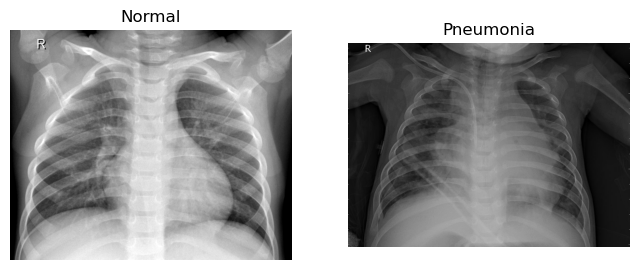

In [13]:
normal_dir = os.path.join(train_dir, "NORMAL")
pneumonia_dir = os.path.join(train_dir, "PNEUMONIA")

# Pick random images
normal_img = random.choice(os.listdir(normal_dir))
pneumonia_img = random.choice(os.listdir(pneumonia_dir))

# Read images
normal_img_path = os.path.join(normal_dir, normal_img)
pneumonia_img_path = os.path.join(pneumonia_dir, pneumonia_img)

normal_img_data = mpimg.imread(normal_img_path)
pneumonia_img_data = mpimg.imread(pneumonia_img_path)

# Plot
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(normal_img_data, cmap='gray')
plt.title("Normal")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pneumonia_img_data, cmap='gray')
plt.title("Pneumonia")
plt.axis("off")
plt.show()


In [ ]:
#Data Preprocessing + Augmentation
IMG_SIZE = 150
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
test_gen = val_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

In [15]:
#Build CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\91720\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Train Model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

C:\Users\91720\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.7697 - loss: 0.5253 - val_accuracy: 0.7500 - val_loss: 0.4444
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.8831 - loss: 0.2821 - val_accuracy: 0.7500 - val_loss: 0.9307
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9077 - loss: 0.2210 - val_accuracy: 0.7500 - val_loss: 0.5776
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.9235 - loss: 0.1921 - val_accuracy: 0.6250 - val_loss: 0.9669
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.9327 - loss: 0.1795 - val_accuracy: 0.6875 - val_loss: 0.5790
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.9332 - loss: 0.1769 - val_accuracy: 0.6875 - val_loss: 0.5436
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.9360 - loss: 0.1579 - val_accuracy: 0.7500 - val_loss: 0.7103
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9405 - loss: 0.1509 - val_accu

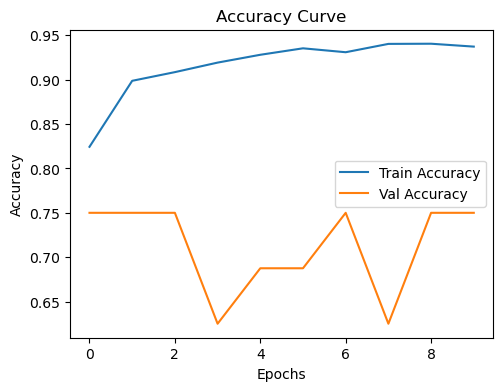

In [25]:
# Plot Training Graphs
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 566ms/step


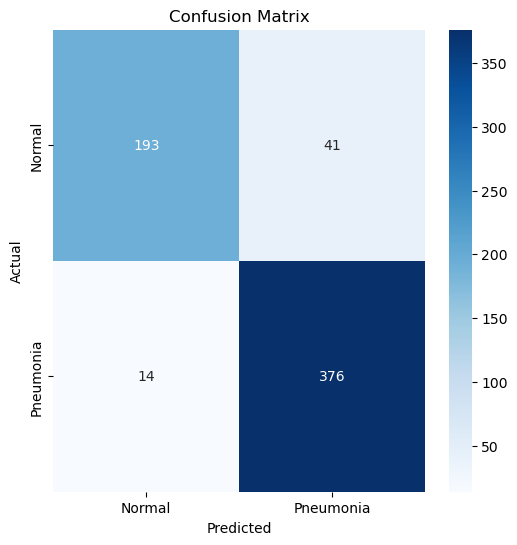

Classification Report:

              precision    recall  f1-score   support

      Normal       0.93      0.82      0.88       234
   Pneumonia       0.90      0.96      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624



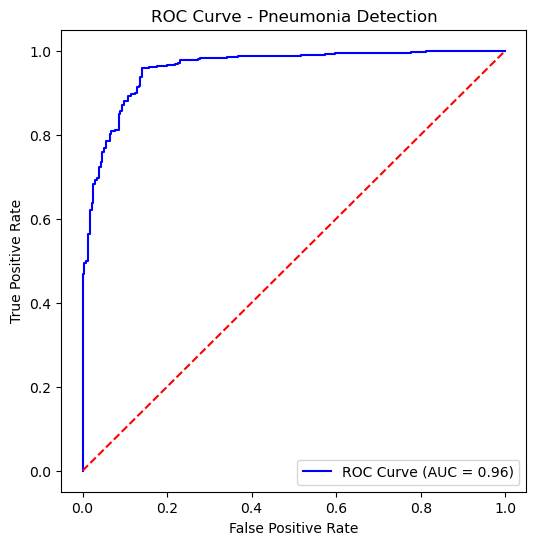

In [23]:
#Model Evaluation on Test Data
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred = model.predict(test_gen)
y_pred_classes = np.where(y_pred > 0.5, 1, 0)
y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=['Normal','Pneumonia'], 
            yticklabels=['Normal','Pneumonia'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=['Normal','Pneumonia']))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Pneumonia Detection")
plt.legend(loc="lower right")
plt.show()
